In [27]:
import pandas as pd
import numpy as np


In [29]:
import os 
os.getcwd()

'/home/suyash/codes/PINN'

In [23]:
os.chdir("../")
os.getcwd()


'/home/suyash/codes'

In [147]:
import pandas as pd

def get_df(input_file):
    rows = []
    current_time = None
    reading_nodes = False

    with open(input_file, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            # Detect time block
            if line.startswith("Time:"):
                try:
                    current_time = float(line.split()[1])
                except:
                    continue
                reading_nodes = False
                continue

            # Detect start of node table
            if line.startswith("Node"):
                reading_nodes = True
                continue

            # Read node rows
            if reading_nodes and line:
                parts = line.split()
                if len(parts) < 3:
                    continue

                try:
                    node = int(parts[0])
                    depth = float(parts[1])
                    pressure_head = float(parts[2])

                    # Optional columns (if present)
                    moisture = float(parts[3]) if len(parts) > 3 else None
                    K = float(parts[4]) if len(parts) > 4 else None
                    C = float(parts[5]) if len(parts) > 5 else None
                    Flux = float(parts[6]) if len(parts) > 6 else None
                    Sink = float(parts[7]) if len(parts) > 7 else None
                    Temp = float(parts[-1]) if len(parts) > 8 else None

                    rows.append([
                        current_time,
                        node,
                        depth,
                        pressure_head,
                        moisture,
                        K,
                        C,
                        Flux,
                        Sink,
                        Temp
                    ])

                except:
                    continue

    # Create DataFrame
    df = pd.DataFrame(rows, columns=[
        "Time_days",
        "Node",
        "Depth_m",
        "Pressure_Head",
        "Moisture",
        "Hydraulic_Conductivity",
        "Specific_Moisture_Capacity",
        "Flux",
        "Sink",
        "Temperature_C"
    ])

    return df

In [149]:
import pandas as pd

file = "dataset/first.out"

data = []

with open(file) as f:
    for line in f:
        parts = line.split()
        
        # data rows start with numeric time
        if len(parts) >= 10:
            try:
                time = float(parts[0])
                
                h_783 = float(parts[7])
                theta_783 = float(parts[8])
                flux_783 = float(parts[9])
                
                data.append([time, h_783, theta_783, flux_783])
            except:
                pass

df_783 = pd.DataFrame(data, columns=[
    "Time_hours",
    "PressureHead_783",
    "Theta_783",
    "Flux_783"
])

print(df_783.head())
df_783['z']= 48.03

   Time_hours  PressureHead_783  Theta_783  Flux_783
0      0.0010             -2.10     0.3199  -0.00417
1      0.0023             -2.06     0.3199  -0.00414
2      0.0040             -2.02     0.3199  -0.00412
3      0.0062             -1.98     0.3199  -0.00413
4      0.0090             -1.94     0.3199  -0.00413


In [175]:
import numpy as np

def calculate_theta_van_genuchten(pressure_head, theta_r, theta_s, alpha, n):
    """
    Calculates volumetric water content (Moisture) from Pressure Head 
    using the van Genuchten equation.
    """
    # Calculate m based on Mualem's restriction
    m = 1.0 - (1.0 / n)
    
    # Take the absolute value of the pressure head for the equation
    # (van Genuchten uses positive suction values)
    suction = np.abs(pressure_head)
    
    # Calculate Moisture (theta) for unsaturated conditions
    theta = theta_r + (theta_s - theta_r) / ((1.0 + (alpha * suction)**n)**m)
    
    # If pressure head is >= 0, the soil is fully saturated (theta = theta_s)
    # np.where works like an if/else statement for the entire column
    theta_final = np.where(pressure_head >= 0, theta_s, theta)
    
    return theta_final

# --- Example Application ---

# Replace these 4 values with the exact numbers from your HYDRUS soil catalog
THETA_R = 0.05
THETA_S = 0.38  
ALPHA = 1     
N_PARAM = 1.56

# Calculate the new column directly from your Pressure_Head column
df_783['Calculated_Moisture'] = calculate_theta_van_genuchten(
    df_783['PressureHead_783'], 
    THETA_R, 
    THETA_S, 
    ALPHA, 
    N_PARAM
)

In [176]:
df_783.head()

,Time_hours,PressureHead_783,Theta_783,Flux_783,z,Factor_of_Safety,Calculated_Moisture
0,0.0010,-2.10,0.3199,-0.00417,48.03,0.617640,0.247453
1,0.0023,-2.06,0.3199,-0.00414,48.03,0.617633,0.249072
2,0.0040,-2.02,0.3199,-0.00412,48.03,0.617625,0.250723
3,0.0062,-1.98,0.3199,-0.00413,48.03,0.617616,0.252409
4,0.0090,-1.94,0.3199,-0.00413,48.03,0.617608,0.254130


In [177]:
import numpy as np

# 1. Define Constants
gamma_w = 9.81
gamma_dry = 21.7  
c_prime = 6.75
phi_deg = 28.55
beta_deg = 40.0   
z= 48.03
# Convert angles to radians
phi_rad = np.radians(phi_deg)
beta_rad = np.radians(beta_deg)

# FIX 1: Create an absolute depth array to prevent any negative depth bugs
abs_depth = np.abs(df_783['z'])

# 2. Calculate Pore Water Pressure (u)
positive_head = np.maximum(df_783["PressureHead_783"], 0)
u = positive_head * gamma_w

# 3. Calculate Dynamic Unit Weight (gamma)
dynamic_weight = gamma_dry + (df_783["Calculated_Moisture"] * gamma_w)
#dynamic_weight = df_783["Calculated_Moisture"]
# 4. Calculate Effective Overburden Stress (sigma)
sigma = dynamic_weight * abs_depth * (np.cos(beta_rad) ** 2)

# FIX 2: Prevent negative effective stress if water pressure exceeds soil weight
effective_stress = np.maximum(sigma - u, 0)

# 5. Calculate Driving Shear Stress - The Denominator (tau)
# Now using abs_depth instead of the raw negative df['Depth_m']
denominator = dynamic_weight * abs_depth * np.sin(beta_rad) * np.cos(beta_rad)

# 6. Calculate Resisting Shear Strength - The Numerator
numerator = c_prime + (effective_stress * np.tan(phi_rad))

# 7. Final Factor of Safety Calculation
# FIX 3: Handle division by zero at the surface node
df_783['Factor_of_Safety'] = np.where(
    abs_depth == 0, 
    np.nan,                                   # Set surface nodes to NaN
    numerator / np.maximum(denominator, 1e-9) # Epsilon added for safety
)

In [172]:
# Van Genuchten parameters
THETA_R = 0.05
THETA_S = 0.38
ALPHA = 2     # ← must match your HYDRUS Layer 1
N_PARAM = 1.56

df_783['Calculated_Moisture'] = calculate_theta_van_genuchten(
    df_783['PressureHead_783'], THETA_R, THETA_S, ALPHA, N_PARAM
)

# Constants
gamma_w   = 9.81
gamma_dry = 21.7
c_prime   = 6.75
phi_rad   = np.radians(28.55)
beta_rad  = np.radians(42.0)   # ← fixed
z         = 43.038             # ← fixed

# Dynamic unit weight (FIXED)
dynamic_weight = gamma_dry + (df_783["Calculated_Moisture"] * gamma_w)

# Pore pressure
u = np.maximum(df_783["PressureHead_783"], 0) * gamma_w

# Stresses
sigma      = dynamic_weight * z * np.cos(beta_rad)**2
tau        = dynamic_weight * z * np.sin(beta_rad) * np.cos(beta_rad)
eff_stress = np.maximum(sigma - u, 0)

# Factor of Safety
df_783['Factor_of_Safety'] = np.where(
    z == 0,
    np.nan,
    (c_prime + eff_stress * np.tan(phi_rad)) / np.maximum(tau, 1e-9)
)

In [178]:
df_783.head()

,Time_hours,PressureHead_783,Theta_783,Flux_783,z,Factor_of_Safety,Calculated_Moisture
0,0.0010,-2.10,0.3199,-0.00417,48.03,0.660246,0.247453
1,0.0023,-2.06,0.3199,-0.00414,48.03,0.660238,0.249072
2,0.0040,-2.02,0.3199,-0.00412,48.03,0.660230,0.250723
3,0.0062,-1.98,0.3199,-0.00413,48.03,0.660222,0.252409
4,0.0090,-1.94,0.3199,-0.00413,48.03,0.660214,0.254130


In [179]:
df_783.count()

Time_hours             15155
PressureHead_783       15155
Theta_783              15155
Flux_783               15155
z                      15155
Factor_of_Safety       15155
Calculated_Moisture    15155
dtype: int64

In [180]:
df_783[(df_783['Factor_of_Safety'] > 0) & (df_783['Factor_of_Safety'] < 1)].head(5)

,Time_hours,PressureHead_783,Theta_783,Flux_783,z,Factor_of_Safety,Calculated_Moisture
0,0.0010,-2.10,0.3199,-0.00417,48.03,0.660246,0.247453
1,0.0023,-2.06,0.3199,-0.00414,48.03,0.660238,0.249072
2,0.0040,-2.02,0.3199,-0.00412,48.03,0.660230,0.250723
3,0.0062,-1.98,0.3199,-0.00413,48.03,0.660222,0.252409
4,0.0090,-1.94,0.3199,-0.00413,48.03,0.660214,0.254130


In [181]:
df_783[(df_783['Factor_of_Safety'] > 0) & (df_783['Factor_of_Safety'] < 1)].count()

Time_hours             15155
PressureHead_783       15155
Theta_783              15155
Flux_783               15155
z                      15155
Factor_of_Safety       15155
Calculated_Moisture    15155
dtype: int64

In [158]:
df_783['Factor_of_Safety'].describe()

count    15155.000000
mean         0.514474
std          0.015819
min          0.447427
25%          0.513639
50%          0.513994
75%          0.514704
max          0.659648
Name: Factor_of_Safety, dtype: float64

In [134]:
df= get_df("dataset/Obs_Node.out")
df.head()

,Time_days,Node,Depth_m,Pressure_Head,Moisture,Hydraulic_Conductivity,Specific_Moisture_Capacity,Flux,Sink,Temperature_C


In [97]:
test = pd.DataFrame({
    "positivehead": np.maximum(df["Pressure_Head"], 0)
})
test.head()


,positivehead
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [98]:
gamma_w = 9,81
beta = 40
c_ = 0.5
phi = 25

In [99]:
import math

In [127]:
import numpy as np

# 1. Define Constants
gamma_w = 9.81
gamma_dry = 21.7  
c_prime = 6.75
phi_deg = 28.55
beta_deg = 40.0   

# Convert angles to radians
phi_rad = np.radians(phi_deg)
beta_rad = np.radians(beta_deg)

# FIX 1: Create an absolute depth array to prevent any negative depth bugs
abs_depth = np.abs(df['Depth_m'])

# 2. Calculate Pore Water Pressure (u)
positive_head = np.maximum(df["Pressure_Head"], 0)
u = positive_head * gamma_w

# 3. Calculate Dynamic Unit Weight (gamma)
dynamic_weight = gamma_dry + (df["Moisture"] * gamma_w)

# 4. Calculate Effective Overburden Stress (sigma)
sigma = dynamic_weight * abs_depth * (np.cos(beta_rad) ** 2)

# FIX 2: Prevent negative effective stress if water pressure exceeds soil weight
effective_stress = np.maximum(sigma - u, 0)

# 5. Calculate Driving Shear Stress - The Denominator (tau)
# Now using abs_depth instead of the raw negative df['Depth_m']
denominator = dynamic_weight * abs_depth * np.sin(beta_rad) * np.cos(beta_rad)

# 6. Calculate Resisting Shear Strength - The Numerator
numerator = c_prime + (effective_stress * np.tan(phi_rad))

# 7. Final Factor of Safety Calculation
# FIX 3: Handle division by zero at the surface node
df['Factor_of_Safety'] = np.where(
    abs_depth == 0, 
    np.nan,                                   # Set surface nodes to NaN
    numerator / np.maximum(denominator, 1e-9) # Epsilon added for safety
)

In [128]:
df.head()

,Time_days,Node,Depth_m,Pressure_Head,Moisture,Hydraulic_Conductivity,Specific_Moisture_Capacity,Flux,Sink,Temperature_C,Factor_of_Safety
0,0.0,1,0.0000,-500.000,0.1155,0.001896,0.000072,0.01363,0.0,20.0,NaN
1,0.0,2,-0.0550,-499.550,0.1155,0.001902,0.000072,0.01366,0.0,20.0,11.564217
2,0.0,3,-0.1101,-499.099,0.1156,0.001907,0.000073,0.01371,0.0,20.0,6.101125
3,0.0,4,-0.1651,-498.649,0.1156,0.001913,0.000073,0.01373,0.0,20.0,4.284657
4,0.0,5,-0.2201,-498.199,0.1156,0.001919,0.000073,0.01377,0.0,20.0,3.376010


In [131]:
df[(df['Factor_of_Safety'] > 0) & (df['Factor_of_Safety'] < 1)].head(5)

,Time_days,Node,Depth_m,Pressure_Head,Moisture,Hydraulic_Conductivity,Specific_Moisture_Capacity,Flux,Sink,Temperature_C,Factor_of_Safety
32,0.0,33,-1.7611,-485.591,0.1166,0.002092,0.000076,0.01503,0.0,20.0,0.989161
33,0.0,34,-1.8162,-485.140,0.1166,0.002098,0.000076,0.01508,0.0,20.0,0.978824
34,0.0,35,-1.8712,-484.690,0.1166,0.002105,0.000076,0.01511,0.0,20.0,0.969112
35,0.0,36,-1.9262,-484.240,0.1167,0.002112,0.000076,0.01515,0.0,20.0,0.959942
36,0.0,37,-1.9813,-483.790,0.1167,0.002118,0.000076,0.01522,0.0,20.0,0.951278


In [130]:
df['Factor_of_Safety'].describe()

count    23976.000000
mean         0.727145
std          0.419324
min          0.659317
25%          0.662299
50%          0.669244
75%          0.690239
max         11.564217
Name: Factor_of_Safety, dtype: float64

In [ ]:
final_df = df[["Time_days", "Node", "Depth_m", "Pressure_Head", "Factor_of_Safety"]]
final_df.head()

In [72]:
final_df['Factor_of_Safety'].describe()

/home/suyash/miniconda3/envs/pinn/lib/python3.11/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    2.400000e+04
mean              inf
std               NaN
min     -8.672856e+01
25%      2.259406e-01
50%      3.918271e-01
75%      4.455665e-01
max               inf
Name: Factor_of_Safety, dtype: float64

In [70]:
np.isinf(final_df["Factor_of_Safety"]).sum()

np.int64(24)

In [71]:
final_df[np.isinf(final_df["Factor_of_Safety"])]

,Time_days,Node,Depth_m,Pressure_Head,Factor_of_Safety
0,0.0,1,0.0,-500.000,inf
1000,1.0,1,0.0,-100.000,inf
2000,10.0,1,0.0,-100.000,inf
3000,20.0,1,0.0,-100.000,inf
4000,30.0,1,0.0,-99.188,inf
5000,40.0,1,0.0,-97.588,inf
6000,50.0,1,0.0,-97.797,inf
7000,60.0,1,0.0,-97.196,inf
8000,65.0,1,0.0,-96.954,inf
9000,70.0,1,0.0,-96.790,inf


In [69]:
final_df['Factor_of_Safety'].describe()

/home/suyash/miniconda3/envs/pinn/lib/python3.11/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    2.400000e+04
mean              inf
std               NaN
min     -8.672856e+01
25%      2.259406e-01
50%      3.918271e-01
75%      4.455665e-01
max               inf
Name: Factor_of_Safety, dtype: float64

In [60]:
final_df.describe

<bound method NDFrame.describe of        Time_days  Node  Depth_m  Pressure_Head  Factor_of_Safety
0            0.0     1   0.0000       -500.000               inf
1            0.0     2  -0.0550       -499.550        -93.194064
2            0.0     3  -0.1101       -499.099        -46.273914
3            0.0     4  -0.1651       -498.649        -30.673490
4            0.0     5  -0.2201       -498.199        -22.869733
...          ...   ...      ...            ...               ...
23995      123.0   996 -54.7795        -64.202          0.461489
23996      123.0   997 -54.8346        -64.180          0.461583
23997      123.0   998 -54.8898        -64.165          0.461678
23998      123.0   999 -54.9449        -64.155          0.461772
23999      123.0  1000 -55.0000        -64.152          0.461867

[24000 rows x 5 columns]>

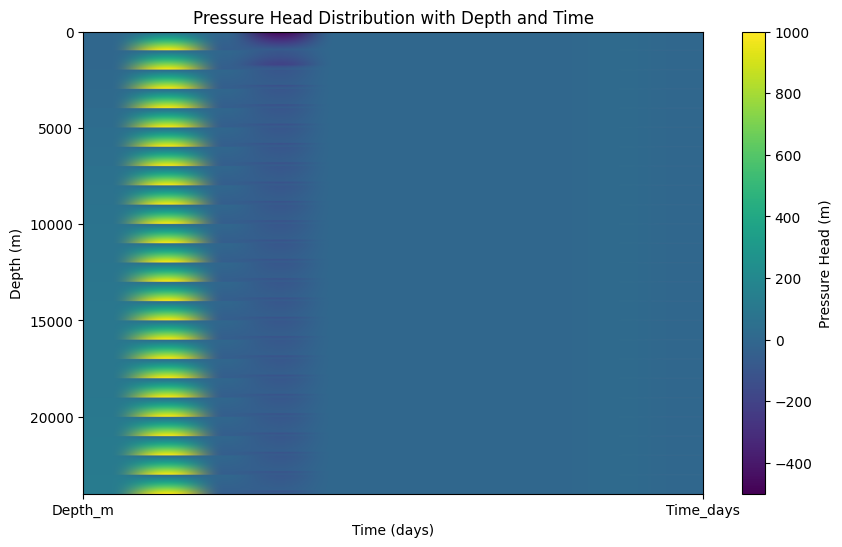

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Create pivot table
pivot = df.pivot(index="Depth_m", columns="Time_days", values="Pressure_Head")

# Sort depth (important!)
pivot = df.sort_index()

plt.figure(figsize=(10,6))

plt.imshow(
    pivot.values,
    aspect='auto',
    origin='lower',
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max()
    ]
)

plt.colorbar(label="Pressure Head (m)")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.title("Pressure Head Distribution with Depth and Time")

plt.gca().invert_yaxis()  # Depth downward
plt.show()

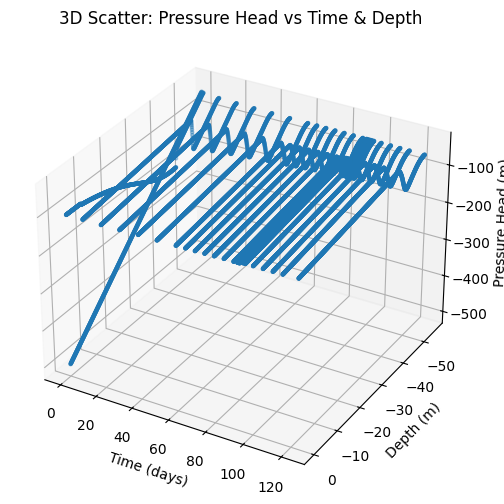

In [50]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Time_days"],
    df["Depth_m"],
    df["Pressure_Head"],
    s=5
)

ax.set_xlabel("Time (days)")
ax.set_ylabel("Depth (m)")
ax.set_zlabel("Pressure Head (m)")

ax.invert_yaxis()  # depth downward
plt.title("3D Scatter: Pressure Head vs Time & Depth")
plt.show()

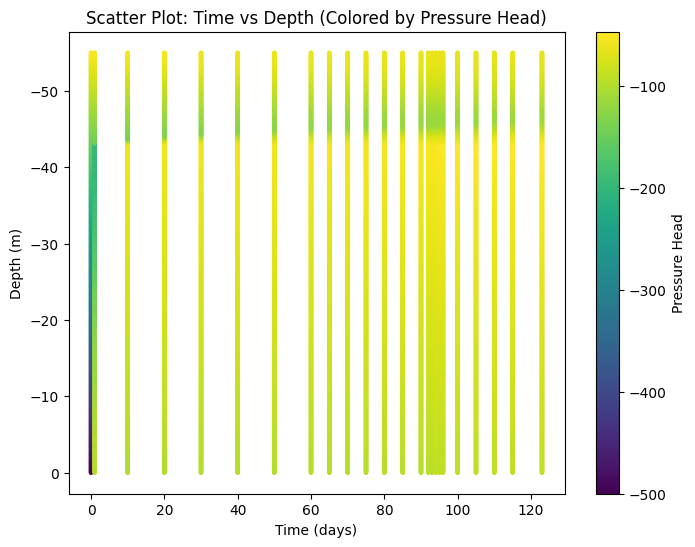

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Time_days"],
    df["Depth_m"],
    c=df["Pressure_Head"],
    s=5
)

plt.colorbar(label="Pressure Head")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.gca().invert_yaxis()

plt.title("Scatter Plot: Time vs Depth (Colored by Pressure Head)")
plt.show()

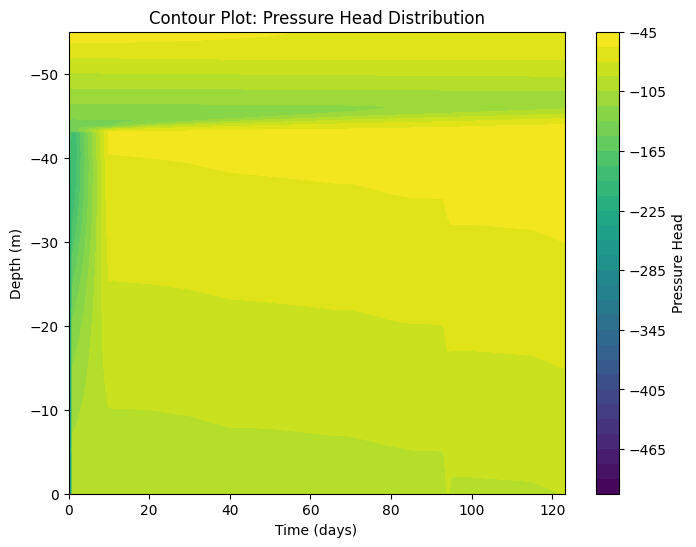

In [52]:
import numpy as np

pivot = df.pivot(index="Depth_m", columns="Time_days", values="Pressure_Head")
pivot = pivot.sort_index()

T, Z = np.meshgrid(pivot.columns, pivot.index)

plt.figure(figsize=(8,6))
plt.contourf(T, Z, pivot.values, levels=30)
plt.colorbar(label="Pressure Head")

plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.gca().invert_yaxis()

plt.title("Contour Plot: Pressure Head Distribution")
plt.show()

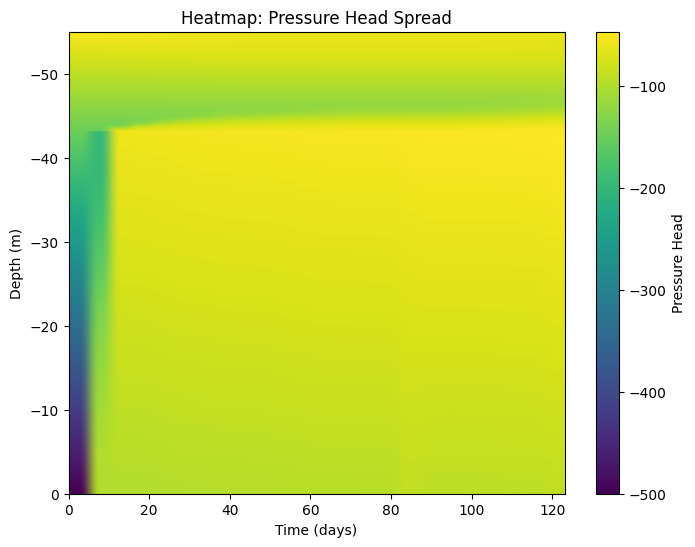

In [53]:
plt.figure(figsize=(8,6))

plt.imshow(
    pivot.values,
    aspect='auto',
    origin='lower',
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max()
    ]
)

plt.colorbar(label="Pressure Head")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.gca().invert_yaxis()

plt.title("Heatmap: Pressure Head Spread")
plt.show()

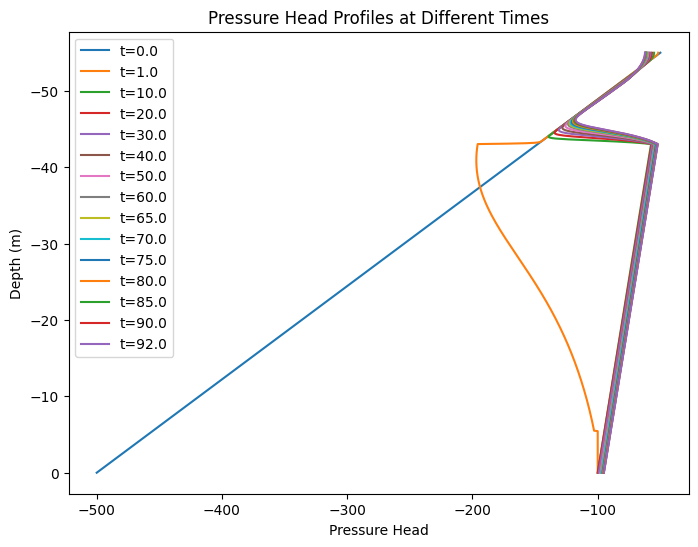

In [54]:
times = df["Time_days"].unique()[:15]  # first 5 times

plt.figure(figsize=(8,6))

for t in times:
    temp = df[df["Time_days"] == t]
    plt.plot(temp["Pressure_Head"], temp["Depth_m"], label=f"t={t}")

plt.gca().invert_yaxis()
plt.xlabel("Pressure Head")
plt.ylabel("Depth (m)")
plt.legend()
plt.title("Pressure Head Profiles at Different Times")
plt.show()

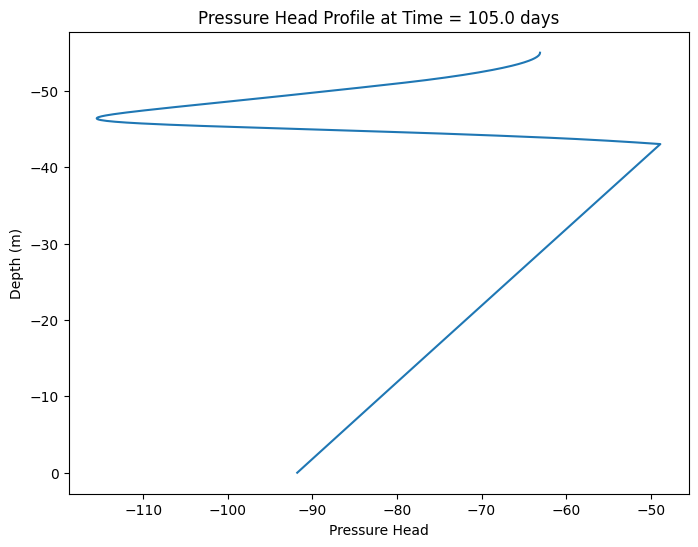

In [55]:
t = df["Time_days"].unique()[20]

plt.figure(figsize=(8,6))

temp = df[df["Time_days"] == t]
plt.plot(temp["Pressure_Head"], temp["Depth_m"])

plt.gca().invert_yaxis()
plt.xlabel("Pressure Head")
plt.ylabel("Depth (m)")
plt.title(f"Pressure Head Profile at Time = {t} days")

plt.show()

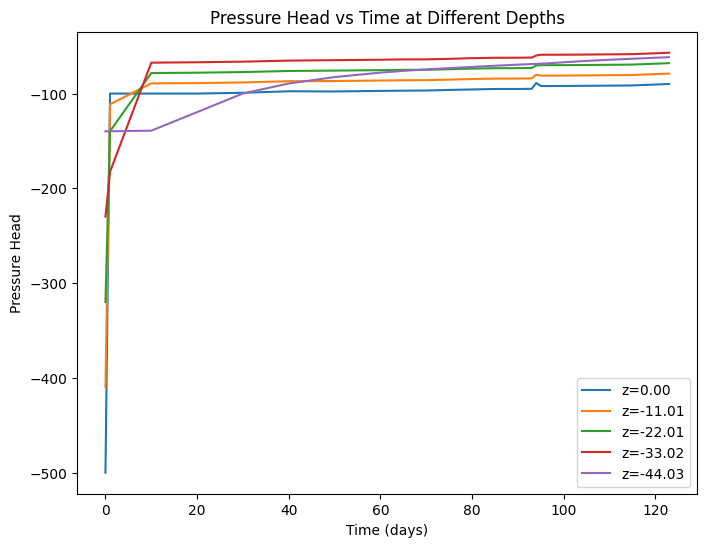

In [56]:

depths = df["Depth_m"].unique()[::200]  # select few depths

plt.figure(figsize=(8,6))

for z in depths:
    temp = df[df["Depth_m"] == z]
    plt.plot(temp["Time_days"], temp["Pressure_Head"], label=f"z={z:.2f}")

plt.xlabel("Time (days)")
plt.ylabel("Pressure Head")
plt.legend()
plt.title("Pressure Head vs Time at Different Depths")
plt.show()